<a href="https://colab.research.google.com/github/Atul245/Computer_vision-mnit/blob/main/Experiment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**SIFT-** **Scale-Invariant Feature Transform**

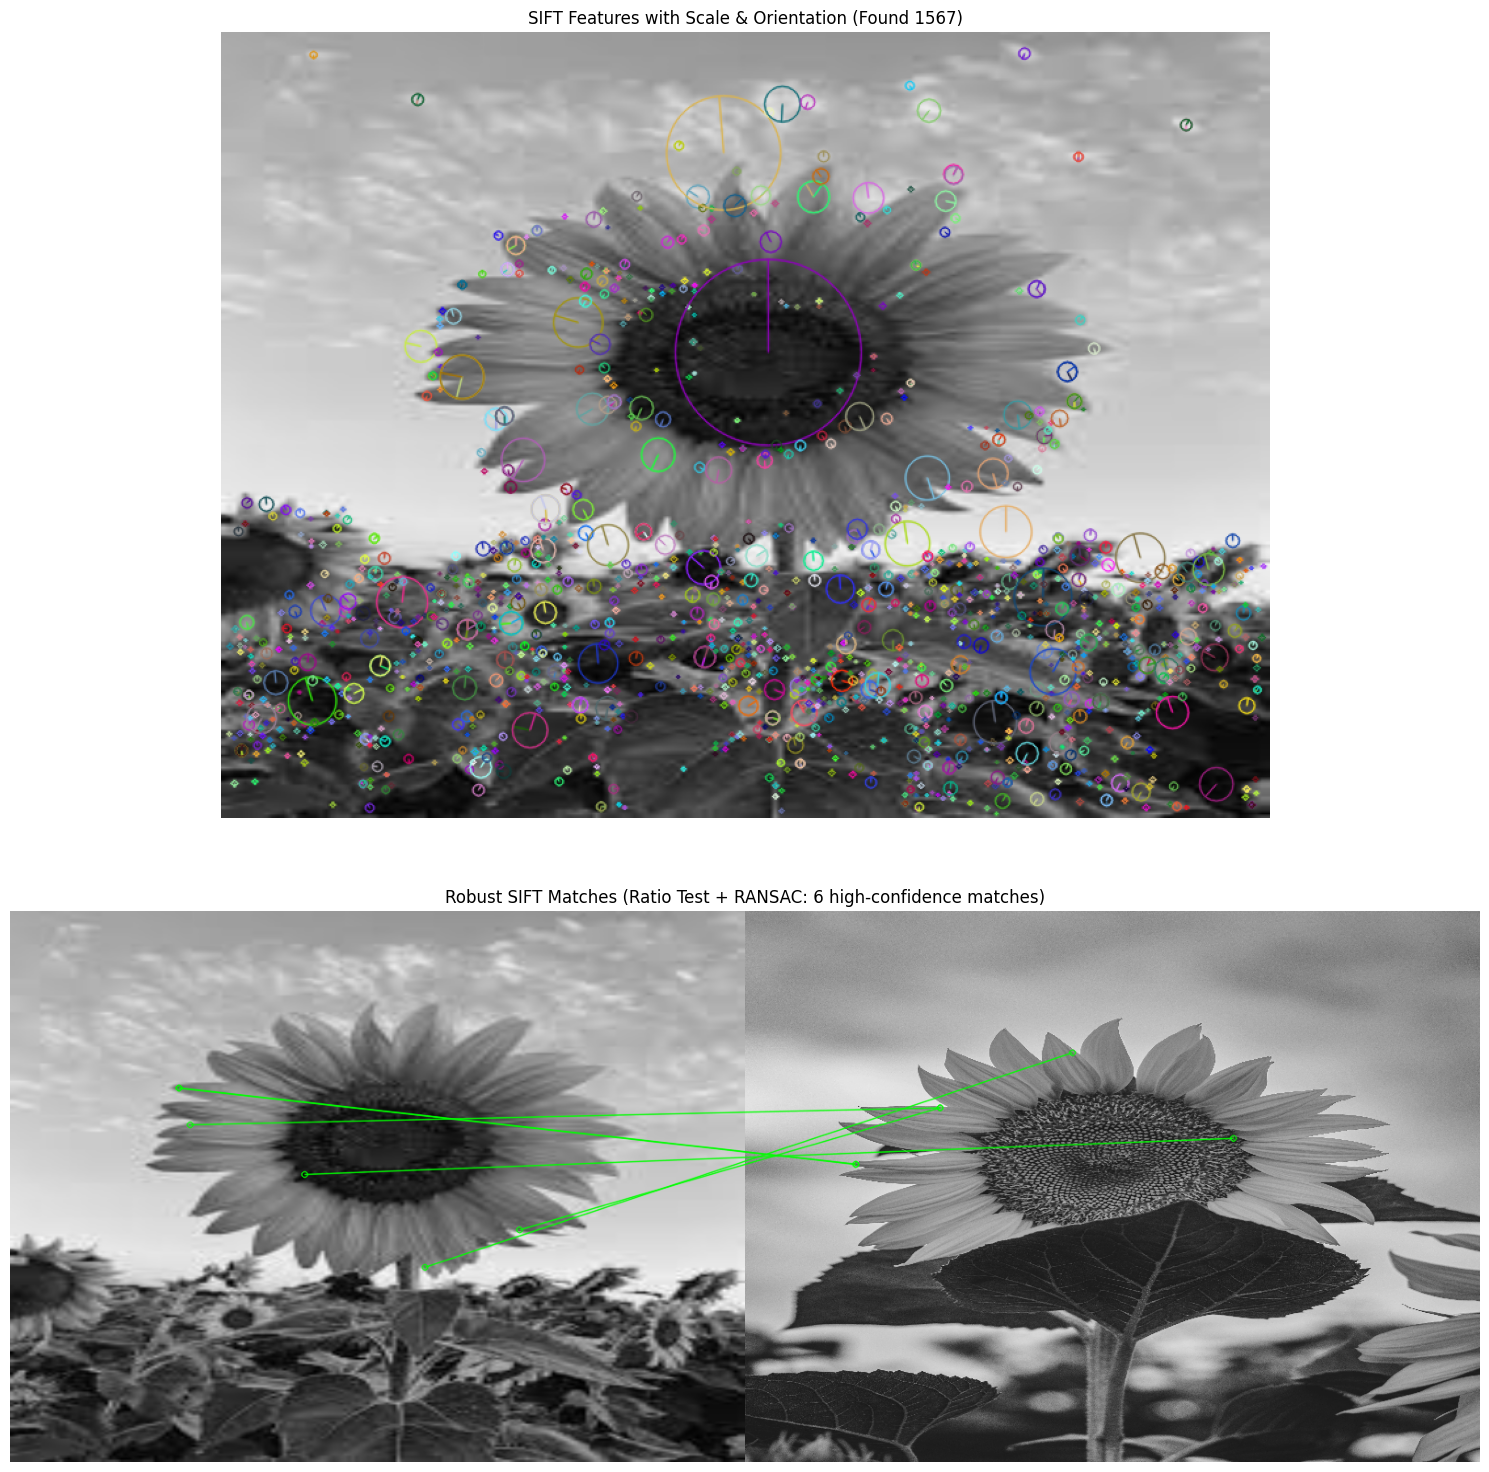

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_1_path = '/content/sf1.jfif'
image_2_path = '/content/sf2.jpg'

def match_sift_features(img_path1, img_path2, display_width=800, display_height=600):

    # 1. Load the images in grayscale
    img1 = cv2.imread(img_path1, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(img_path2, cv2.IMREAD_GRAYSCALE)

    if img1 is None or img2 is None:
        print("Error: Could not load one or both images. Check the paths.")
        return

    # Resize images to a common display size
    img1_resized = cv2.resize(img1, (display_width, display_height))
    img2_resized = cv2.resize(img2, (display_width, display_height))


    sift = cv2.SIFT_create()

    # 3. Detect keypoints and compute descriptors
    keypoints1, descriptors1 = sift.detectAndCompute(img1_resized, None)
    keypoints2, descriptors2 = sift.detectAndCompute(img2_resized, None)

    if descriptors1 is None or descriptors2 is None:
        print("Error: No descriptors found.")
        return


    # Draw circles representing the scale and orientation of the features
    img1_kp = cv2.drawKeypoints(img1_resized, keypoints1, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    img2_kp = cv2.drawKeypoints(img2_resized, keypoints2, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

    # 4. Initialize Brute-Force Matcher & 5. Perform k-NN
    bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
    matches = bf.knnMatch(descriptors1, descriptors2, k=2)

    # 6. Apply Lowe's Ratio Test
    good_matches = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)

    # Convert keypoints to numpy arrays for calculation
    src_pts = np.float32([keypoints1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([keypoints2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    # Find the Homography matrix and an inlier mask
    # This filters out matches that don't make geometric sense between the two images
    if len(good_matches) > 4:
        M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
        matches_mask = mask.ravel().tolist()
    else:
        matches_mask = None

    # 7. Draw the final geometrically verified matches
    # We pass the RANSAC mask to only draw the truly correct matches
    draw_params = dict(matchColor=(0, 255, 0), # draw matches in green
                       singlePointColor=None,
                       matchesMask=matches_mask, # only draw inliers
                       flags=2)

    img_matches = cv2.drawMatches(
        img1_resized, keypoints1,
        img2_resized, keypoints2,
        good_matches, None,
        **draw_params
    )

    # 8. Display Results side-by-side
    fig, axes = plt.subplots(2, 1, figsize=(15, 16))

    # Plot 1: Show the rich keypoints on the first image to visualize scale
    axes[0].imshow(cv2.cvtColor(img1_kp, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"SIFT Features with Scale & Orientation (Found {len(keypoints1)})")
    axes[0].axis('off')

    # Plot 2: Show the final RANSAC-filtered matches
    valid_matches_count = sum(matches_mask) if matches_mask else 0
    axes[1].imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"Robust SIFT Matches (Ratio Test + RANSAC: {valid_matches_count} high-confidence matches)")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# Execution
match_sift_features(image_1_path, image_2_path)

# Next-Level Classification: Sparse vs. Dense Feature Architectures
Traditional computer vision relies heavily on deep neural networks. In this notebook, we take an out-of-the-box approach, building a highly transparent **Bag of Visual Words (BoVW)** pipeline from scratch to compare localized interest points against forced-grid structural extraction.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.cluster import MiniBatchKMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


def build_vocabulary(descriptors_list, vocab_size=150):
    """Clusters extracted features into a Visual Dictionary."""
    print(f"   -> Clustering {len(descriptors_list)} features into {vocab_size} words...")
    kmeans = MiniBatchKMeans(n_clusters=vocab_size, random_state=42, n_init=3)
    kmeans.fit(descriptors_list)
    return kmeans

def build_histograms(image_descriptors, kmeans_model, vocab_size):
    """Converts raw image descriptors into uniform frequency histograms."""
    histograms = []
    for des in image_descriptors:
        hist = np.zeros(vocab_size)
        if len(des) > 0:
            words = kmeans_model.predict(des)
            for w in words:
                hist[w] += 1
            hist = hist / (np.sum(hist) + 1e-5) # L1 Normalization
        histograms.append(hist)
    return np.array(histograms)

In [ ]:
# ==========================================
# 2. Standard SIFT Implementation
# ==========================================

def extract_standard_sift(images, sift):
    """Extracts features only at interesting corners and edges."""
    desc_list = []
    img_desc = []
    for img in images:
        _, des = sift.detectAndCompute(img, None)
        if des is not None:
            desc_list.extend(des)
            img_desc.append(des)
        else:
            img_desc.append(np.array([]))
    return np.array(desc_list), img_desc

In [ ]:
# ==========================================
# 3. Dense SIFT Implementation
# ==========================================

def compute_dense_keypoints(image, step_size=6, kp_size=10):
    """Forces feature extraction on a rigid mathematical grid."""
    h, w = image.shape
    keypoints = [cv2.KeyPoint(float(x), float(y), float(kp_size))
                 for y in range(0, h, step_size)
                 for x in range(0, w, step_size)]
    return keypoints

def extract_dense_sift(images, sift, step_size=6):
    """Computes descriptors across the entire forced grid."""
    desc_list = []
    img_desc = []
    for img in images:
        kp = compute_dense_keypoints(img, step_size)
        _, des = sift.compute(img, kp)
        if des is not None:
            desc_list.extend(des)
            img_desc.append(des)
        else:
            img_desc.append(np.array([]))
    return np.array(desc_list), img_desc

In [ ]:
print("Downloading Olivetti Faces dataset...")
faces = fetch_olivetti_faces(shuffle=True, random_state=42)
X_images = [np.uint8(img * 255) for img in faces.images]
y_labels = faces.target

X_train, X_test, y_train, y_test = train_test_split(
    X_images, y_labels, test_size=0.2, random_state=42
)

sift_engine = cv2.SIFT_create()
VOCAB_SIZE = 150
K_NEIGHBORS = 3

In [ ]:
# --- RUN: Standard SIFT Pipeline ---
print("\n[STARTING PIPELINE 1: STANDARD SIFT]")
std_train_desc, std_train_img_desc = extract_standard_sift(X_train, sift_engine)
std_test_desc, std_test_img_desc = extract_standard_sift(X_test, sift_engine)

std_kmeans = build_vocabulary(std_train_desc, VOCAB_SIZE)
std_X_train_hist = build_histograms(std_train_img_desc, std_kmeans, VOCAB_SIZE)
std_X_test_hist = build_histograms(std_test_img_desc, std_kmeans, VOCAB_SIZE)

std_knn = KNeighborsClassifier(n_neighbors=K_NEIGHBORS, metric='euclidean')
std_knn.fit(std_X_train_hist, y_train)
std_accuracy = accuracy_score(y_test, std_knn.predict(std_X_test_hist))


[STARTING PIPELINE 1: STANDARD SIFT]
   -> Clustering 13052 features into 150 words...


In [ ]:
# --- RUN: Dense SIFT Pipeline ---
print("\n[STARTING PIPELINE 2: DENSE SIFT]")
dense_train_desc, dense_train_img_desc = extract_dense_sift(X_train, sift_engine, step_size=6)
dense_test_desc, dense_test_img_desc = extract_dense_sift(X_test, sift_engine, step_size=6)

dense_kmeans = build_vocabulary(dense_train_desc, VOCAB_SIZE)
dense_X_train_hist = build_histograms(dense_train_img_desc, dense_kmeans, VOCAB_SIZE)
dense_X_test_hist = build_histograms(dense_test_img_desc, dense_kmeans, VOCAB_SIZE)

dense_knn = KNeighborsClassifier(n_neighbors=K_NEIGHBORS, metric='euclidean')
dense_knn.fit(dense_X_train_hist, y_train)
dense_accuracy = accuracy_score(y_test, dense_knn.predict(dense_X_test_hist))


[STARTING PIPELINE 2: DENSE SIFT]
   -> Clustering 38720 features into 150 words...


In [ ]:
print(f"\n========================================")
print(f"RESULTS: k-NN CLASSIFICATION (k={K_NEIGHBORS})")
print(f"Standard SIFT Accuracy: {std_accuracy * 100:.2f}%")
print(f"Dense SIFT Accuracy:    {dense_accuracy * 100:.2f}%")
print(f"========================================")


RESULTS: k-NN CLASSIFICATION (k=3)
Standard SIFT Accuracy: 46.25%
Dense SIFT Accuracy:    46.25%


In [ ]:
# Visualize the extraction difference on a sample image
sample_img = X_test[0]

# Get Standard Keypoints
std_kp = sift_engine.detect(sample_img, None)
img_std_kp = cv2.drawKeypoints(sample_img, std_kp, None, color=(0, 255, 0), flags=0)

# Get Dense Keypoints
dense_kp = compute_dense_keypoints(sample_img, step_size=6)
img_dense_kp = cv2.drawKeypoints(sample_img, dense_kp, None, color=(255, 0, 0), flags=0)

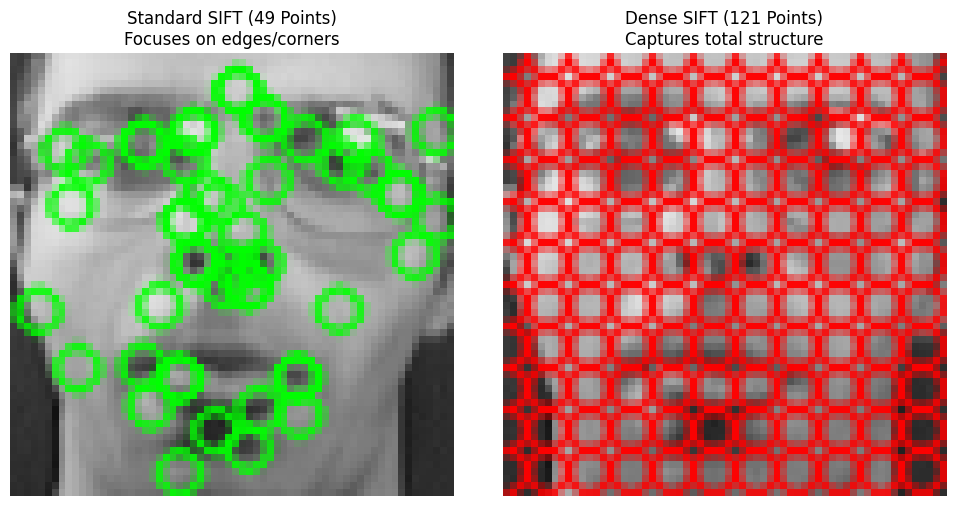

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_std_kp)
plt.title(f"Standard SIFT ({len(std_kp)} Points)\nFocuses on edges/corners")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_dense_kp)
plt.title(f"Dense SIFT ({len(dense_kp)} Points)\nCaptures total structure")
plt.axis('off')

plt.tight_layout()
plt.show()

# BAYES CLASSIFIER

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

def gauss(m, v, x):
    """
    Evaluates a Gaussian in d-dimensions with independent
    mean m and variance v at the points in (the rows of) x.
    """
    if len(x.shape) == 1:
        n, d = 1, x.shape[0]
    else:
        n, d = x.shape

    # covariance matrix, subtract mean
    S = np.diag(1/v)
    x = x - m

    # product of probabilities
    y = np.exp(-0.5 * np.diag(np.dot(x, np.dot(S, x.T))))

    # normalize and return
    return y * (2 * np.pi) ** (-d/2.0) / (np.sqrt(np.prod(v)) + 1e-6)


class BayesClassifier(object):
    def __init__(self):
        """ Initialize classifier with training data. """
        self.labels = []
        self.mean = []
        self.var = []
        self.n = 0

    def train(self, data, labels=None):
        """
        Train on data (list of arrays n*dim).
        Labels are optional, default is 0...n-1.
        """
        if labels is None:
            labels = range(len(data))
        self.labels = labels
        self.n = len(labels)

        for c in data:
            self.mean.append(np.mean(c, axis=0))
            self.var.append(np.var(c, axis=0))

    def classify(self, points):
        """
        Classify the points by computing probabilities
        for each class and return most probable label.
        """
        # compute probabilities for each class
        est_prob = np.array([gauss(m, v, points) for m, v in zip(self.mean, self.var)])

        # get index of highest probability, this gives class label
        ndx = est_prob.argmax(axis=0)
        est_labels = np.array([self.labels[n] for n in ndx])

        return est_labels, est_prob


print("Compressing High-Dimensional Data using PCA...")
# Keep the 50 dimensions with the most variance
DIMENSIONS = 50
pca = PCA(n_components=DIMENSIONS)

# Fit PCA on the training histograms we generated in the previous steps
X_train_pca = pca.fit_transform(dense_X_train_hist)
X_test_pca = pca.transform(dense_X_test_hist)

# The custom BayesClassifier expects a list of arrays (one array for each class)
# We need to format our data to match this requirement
unique_classes = np.unique(y_train)
bayes_training_data = []

for c in unique_classes:
    # Filter the training data to only include rows matching the current class
    class_data = X_train_pca[y_train == c]
    bayes_training_data.append(class_data)

print("Training Gaussian Naive Bayes Classifier...")
bc = BayesClassifier()
bc.train(bayes_training_data, labels=unique_classes)

print("Testing Model on Unseen Data...")
# We only want the labels, so we take index [0] from the return tuple
bayes_predictions = bc.classify(X_test_pca)[0]

# Calculate Accuracy
bayes_acc = accuracy_score(y_test, bayes_predictions)

print(f"\n========================================")
print(f"RESULTS: PCA + BAYES CLASSIFICATION")
print(f"Accuracy (50 Dimensions): {bayes_acc * 100:.2f}%")
print(f"========================================")

Compressing High-Dimensional Data using PCA...
Training Gaussian Naive Bayes Classifier...
Testing Model on Unseen Data...

RESULTS: PCA + BAYES CLASSIFICATION
Accuracy (50 Dimensions): 45.00%


# SUPPORT VECTOR MACHINE

In [ ]:
from sklearn.svm import SVC
import time


print("Training SVM with Linear Kernel...")
start_time = time.time()

# We use the Dense SIFT histograms
svm_linear = SVC(kernel='linear', C=1.0)
svm_linear.fit(dense_X_train_hist, y_train)

linear_predictions = svm_linear.predict(dense_X_test_hist)
linear_accuracy = accuracy_score(y_test, linear_predictions)

linear_time = time.time() - start_time


print("Training SVM with RBF (Radial Basis Function) Kernel...")
start_time = time.time()

# The RBF kernel maps features using an exponential function, usually a very effective choice.
svm_rbf = SVC(kernel='rbf', C=10.0, gamma='scale')
svm_rbf.fit(dense_X_train_hist, y_train)

rbf_predictions = svm_rbf.predict(dense_X_test_hist)
rbf_accuracy = accuracy_score(y_test, rbf_predictions)

rbf_time = time.time() - start_time

# ==========================================
# 3. The Ultimate Pipeline Showdown Results
# ==========================================
print(f"\n==================================================")
print(f"🏆 ULTIMATE CLASSIFICATION PIPELINE RESULTS 🏆")
print(f"==================================================")
print(f"1. k-Nearest Neighbors (Standard SIFT): {std_accuracy * 100:.2f}%")
print(f"2. k-Nearest Neighbors (Dense SIFT):    {dense_accuracy * 100:.2f}%")
print(f"3. Gaussian Naive Bayes (PCA 50-Dim):   {bayes_acc * 100:.2f}%")
print(f"4. SVM (Linear Kernel):                 {linear_accuracy * 100:.2f}% (Time: {linear_time:.2f}s)")
print(f"5. SVM (RBF Kernel):                    {rbf_accuracy * 100:.2f}% (Time: {rbf_time:.2f}s)")
print(f"==================================================")

Training SVM with Linear Kernel...
Training SVM with RBF (Radial Basis Function) Kernel...

🏆 ULTIMATE CLASSIFICATION PIPELINE RESULTS 🏆
1. k-Nearest Neighbors (Standard SIFT): 46.25%
2. k-Nearest Neighbors (Dense SIFT):    46.25%
3. Gaussian Naive Bayes (PCA 50-Dim):   45.00%
4. SVM (Linear Kernel):                 0.00% (Time: 0.06s)
5. SVM (RBF Kernel):                    71.25% (Time: 0.11s)
